In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt

import good
from good.reload import deep_reload

This nodebook shows an example of how to run GOOD for a pre-built graph. In this case the WECC example graph is loaded and run for 7 days with results plotted. The same is done with flexible base loads in the second example.

The first step is to load the graph. Let's use the WECC example.

In [6]:
graph = good.graph.graph_from_json('Examples/WEC.json')
# graph = good.graph.graph_from_json('../good_datasets/Outputs/WEC.json')

graph.nodes

NodeView(('WECC_AZ', 'WECC_CO', 'WECC_ID', 'WECC_IID', 'WECC_MT', 'WECC_NM', 'WECC_NNV', 'WECC_PNW', 'WECC_SCE', 'WECC_SNV', 'WECC_UT', 'WECC_WY', 'WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE'))

Let's make this sepcific to California by making a subgraph

In [7]:
nodes = ['WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID' , 'WECC_SCE']
graph = good.graph.subgraph(graph, nodes)
graph.nodes

NodeView(('WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID', 'WECC_SCE'))

In [8]:
for source, node in graph._node.items():

    node['assets'] = {v['id']: v for v in node['assets']}

In [17]:
good.graph.graph_to_json(graph, 'Examples/California.json')

First we will consider the current grid with no capacity expanison and no load shifting.

We will also not apply RPS constraints

In [18]:
policies = good.utilities.read_json('Examples/RPS.json')

policies = {v['id']: v for v in policies}

good.utilities.write_json(policies, 'Examples/policies.json')

In [20]:
'''
Loading graph and policies - with no capex
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/California.json')

policies = good.utilities.read_json('Examples/policies.json')

for source, node in graph._node.items():
    for key, asset in node.get('assets', {}).items():

        asset['capex_capacity'] = 0

In [31]:
graph._node['WEC_SDGE'].keys()

dict_keys(['_class', 'assets', 'profiles'])

In [30]:
network.graph._node['WEC_SDGE']['object'].exports

{}

In [33]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(graph)

'''
Building the model
'''

network.build()

# network.size()

Parameters Built: 0.20106720924377441
Variables Built: 0.14857816696166992
Constraints Built: 1.5830833911895752
Objective Built: 0.10836482048034668


In [34]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 2.912437915802002
Results Collected: 1.5974013805389404


In [35]:
import pyomo.environ as pe

pe.value(network.model.objective)

61870018.984524235

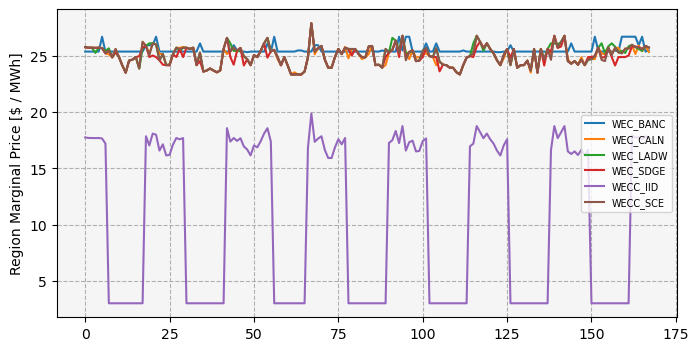

In [36]:
fig, ax = plt.subplots(1, 1, figsize = (8, 4))

for source, node in graph._node.items():

    ax.plot(
        np.array(results[source]['clearing_price']) * 3.6e9,
        label = source,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Region Marginal Price [$ / MWh]',
}

ax.set(**kw)

kw = {
    'ls': '--',
}

ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

ax.legend(**kw)

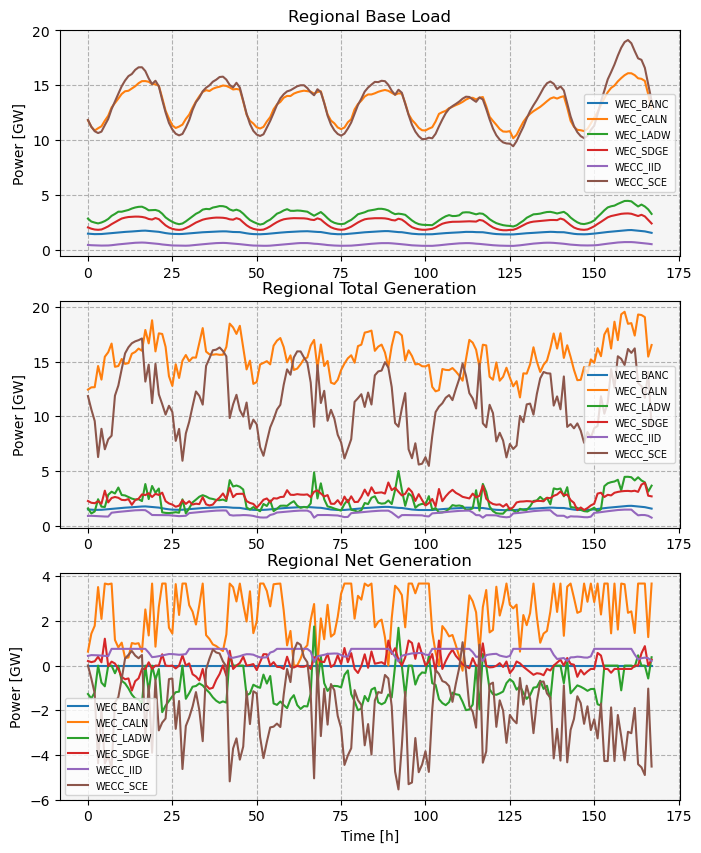

In [37]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in graph._node.items():

    ax[0].plot(
        -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
        label = source,
    )
    
    ax[0].set_title('Regional Base Load')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
    )

    ax[1].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[1].set_title('Regional Total Generation')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items()]
    )

    ax[2].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[2].set_title('Regional Net Generation')
    ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

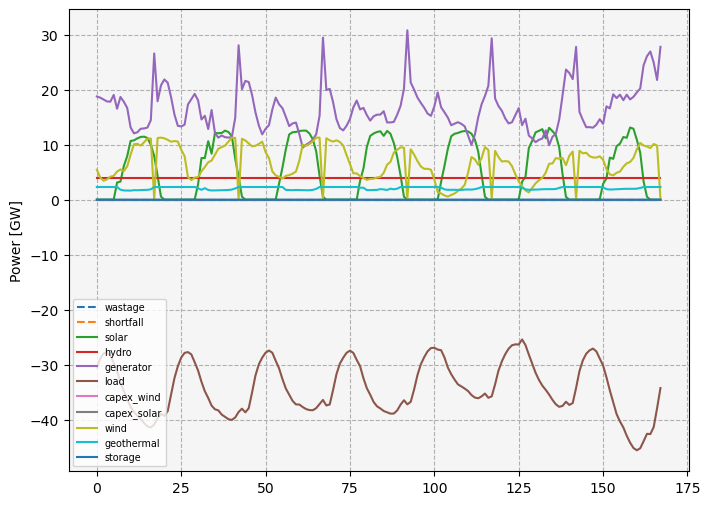

In [39]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets'].values():

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

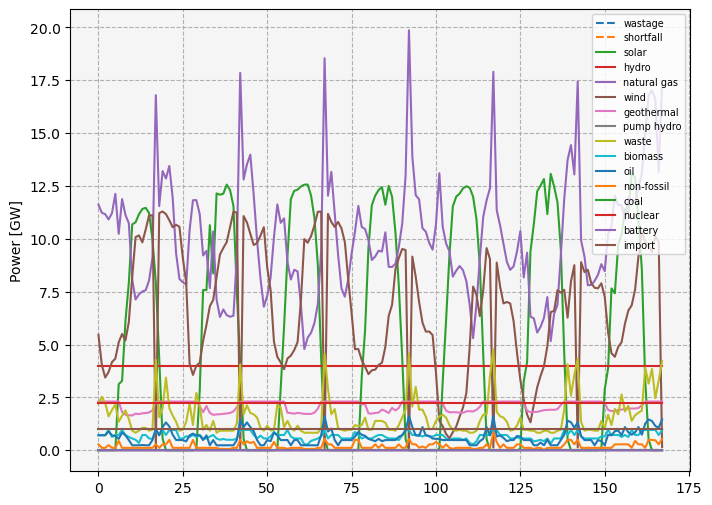

In [40]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets'].values():

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in gen_amounts:

            gen_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

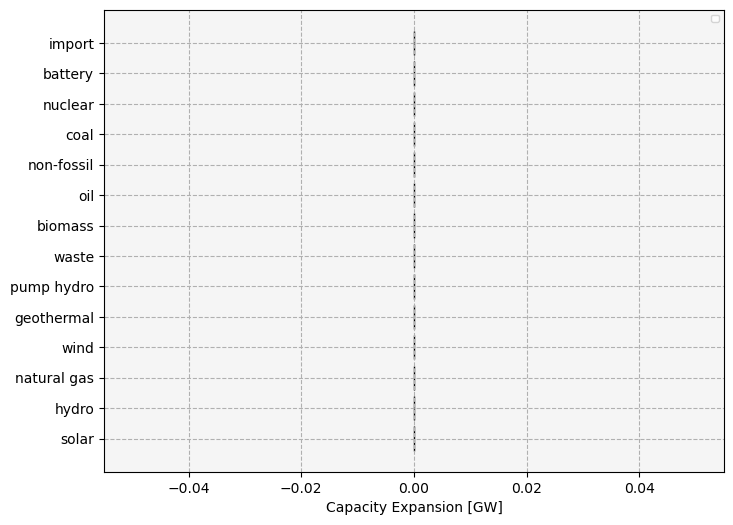

In [41]:
capex_amounts = {}

for source, node in graph._node.items():

    for asset in node['assets'].values():

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in capex_amounts:

            capex_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['capex']]
            )

        else:

            capex_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['capex']]
            )

for key, val in capex_amounts.items():

    capex_amounts[key] = np.vstack(val).sum(axis = 0)[0] / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

kw = {
    'color': 'xkcd:seafoam',
    'ec': 'k',
}

ax.barh(list(capex_amounts.keys()), list(capex_amounts.values()), **kw)

kw = {
    'facecolor': 'whitesmoke',
    'xlabel': 'Capacity Expansion [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

Next we will consider the current grid with allowed capacity expanison and no load shifting.

In [90]:
policies_list = good.utilities.read_json('Examples/RPS.json')

policies = {}

for v in policies_list:

    if v['jurisdiction'] != 'CA':

        continue

    policy = {
        '_class': 'Portfolio_Standard',
        'ratio': v['generation_portion'],
        'inclusion_criteria': (
            {i: p for i, p in enumerate(v['inclusion_criteria'])}
        ),
        'exclusion_criteria': (
            {i: p for i, p in enumerate(v['exclusion_criteria'])}
        ),
    }

    policies[v['id']] = policy

good.utilities.write_json(policies, 'Examples/policies.json')

In [283]:
'''
Loading graph and policies
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/California.json')

policies = {
    'california_ps':{
        '_class': 'Portfolio_Standard',
        'ratio': 0.45,
        'inclusion_criteria': {
            0: "lambda a: a.get('renewable', True)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
        'exclusion_criteria': {
            0: "lambda a: not a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
    },
    'california_ct': {
        '_class': 'Capacity_Target',
        'target': 70e9,
        'inclusion_criteria': {
            0: "lambda a: a.get('renewable', True)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
    },
    'california_rm' : {
        '_class': 'Reserve_Margin',
        'margin': .1,
        'sign': -1,
        'demand_criteria': {
            2: "lambda a: a.get('type', '') == 'load'",
        },
        'supply_criteria': {
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
        },
    },
}

for source, node in graph._node.items():
    for key, asset in node.get('assets', {}).items():

        asset['capex_cost'] /= (52 * 5)

In [288]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(
    graph, policies = policies
)

'''
Building the model
'''

network.build()

network.size()

Parameters Built: 0.2518432140350342
Variables Built: 0.1550276279449463
Constraints Built: 2.139923095703125
Objective Built: 0.6752252578735352


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 120810, continuous_variables = 46537, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 46537), overall = Bunch(binary_variables = 0, constraints = 120810, continuous_variables = 46537, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 46537), warning = Bunch(unassociated_disjuncts = 0))

In [289]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

setattr(network.model, 'california_ps::ratio', .7)

network.solve(**kw)
solution = network.solution

Problem Solved: 2.8550851345062256
Results Collected: 1.6008355617523193


AttributeError: 'Network' object has no attribute 'results'

In [290]:
solution = network.solution

In [273]:
import pyomo.environ as pe

pe.value(network.model.objective)

3.861807822735847e+16

In [81]:
import pyomo.environ as pe

pe.value(network.model.objective)

27765916.44016179

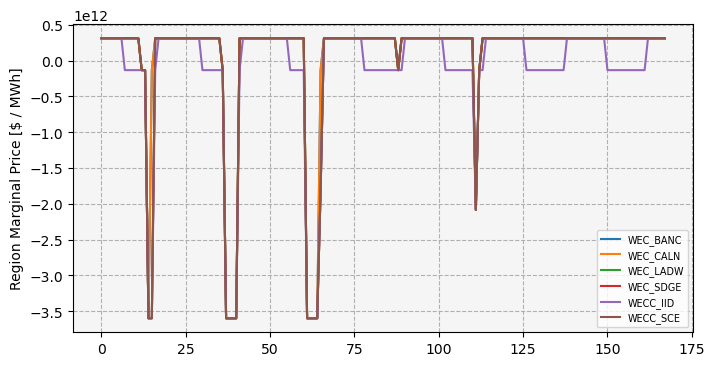

In [274]:
fig, ax = plt.subplots(1, 1, figsize = (8, 4))

for source, node in graph._node.items():

    ax.plot(
        np.array(results[source]['clearing_price']) * 3.6e9,
        label = source,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Region Marginal Price [$ / MWh]',
}

ax.set(**kw)

kw = {
    'ls': '--',
}

ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

ax.legend(**kw)

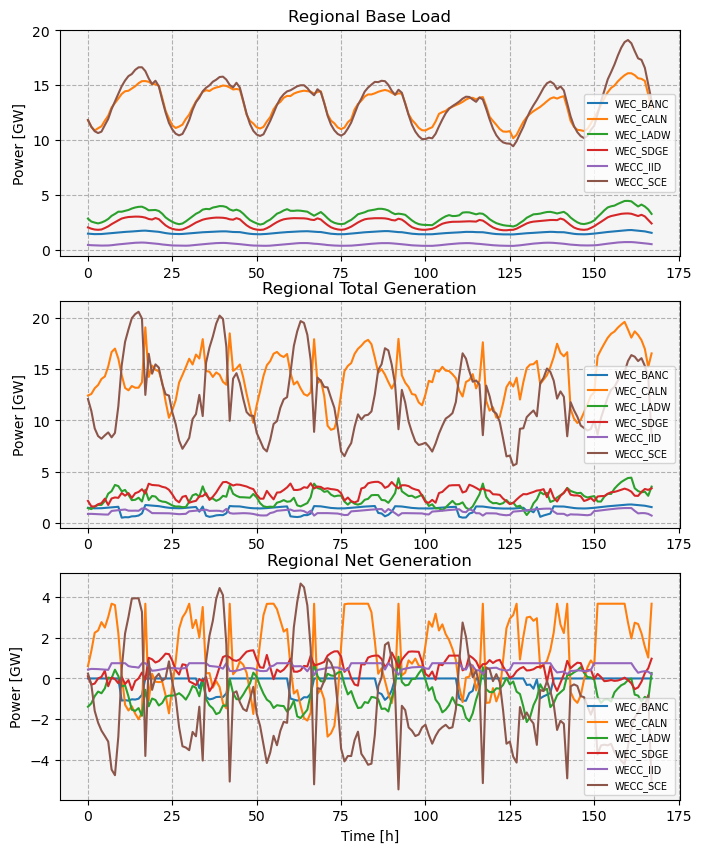

In [275]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in graph._node.items():

    ax[0].plot(
        -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
        label = source,
    )
    
    ax[0].set_title('Regional Base Load')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
    )

    ax[1].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[1].set_title('Regional Total Generation')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items()]
    )

    ax[2].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[2].set_title('Regional Net Generation')
    ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

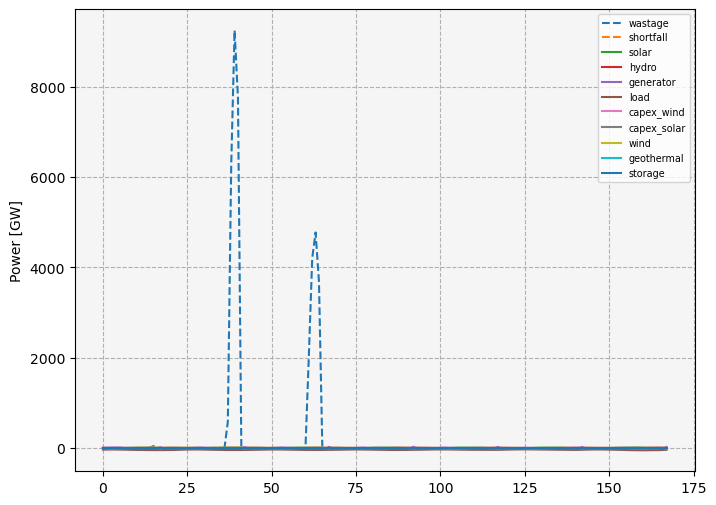

In [276]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets'].values():

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

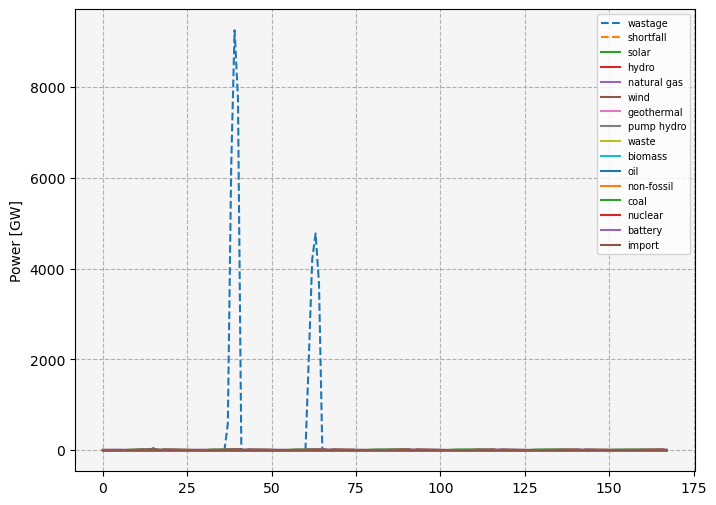

In [277]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets'].values():

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in gen_amounts:

            gen_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

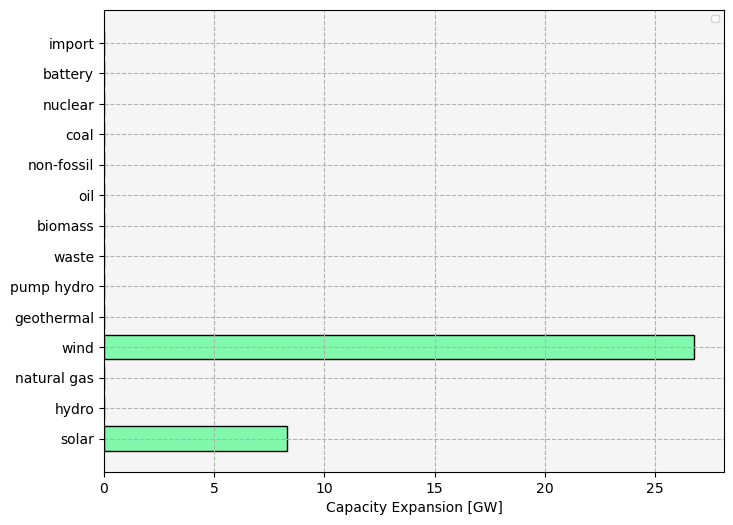

In [278]:
capex_amounts = {}

for source, node in graph._node.items():

    for asset in node['assets'].values():

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in capex_amounts:

            capex_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['capex']]
            )

        else:

            capex_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['capex']]
            )

for key, val in capex_amounts.items():

    capex_amounts[key] = np.vstack(val).sum(axis = 0)[0] / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

kw = {
    'color': 'xkcd:seafoam',
    'ec': 'k',
}

ax.barh(list(capex_amounts.keys()), list(capex_amounts.values()), **kw)

kw = {
    'facecolor': 'whitesmoke',
    'xlabel': 'Capacity Expansion [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

Finally we will consider the current grid with allowed capacity expanison and allowed load shifting.

In [12]:
'''
Loading graph and policies
'''
deep_reload(good)

# graph = good.graph.graph_from_json('Examples/WEC.json')
graph = good.graph.graph_from_json('../good_datasets/Outputs/WEC.json')

nodes = ['WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID' , 'WECC_SCE']
graph = good.graph.subgraph(graph, nodes)

policies = good.utilities.read_json('Examples/RPS.json')

for source, node in graph._node.items():
    for asset in node.get('assets', []):

        asset['capex_cost'] /= (52 * 5)

        if asset['type'] == 'load':

            asset['shift_portion'] = .25
            asset['shift_window'] = 24
            asset['capex_cost'] /= (52 * 5)

        # if asset['_class'] == 'Store':

        #     asset['capex_capacity'] = np.inf
        #     asset['capex_cost'] = 1e-3 / (52 * 5)
        #     asset['production_rate'] = .25
        #     asset['consumption_rate'] = .25

In [13]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e0,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e0,
}

network = good.optimization.network.Network(**kw).from_graph(graph, policies = policies)

'''
Building the model
'''

network.build()

network.size()

Parameters Built: 0.5976815223693848
Variables Built: 0.17589616775512695
Constraints Built: 2.123274803161621
Objective Built: 0.13337254524230957


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 125747, continuous_variables = 50572, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 50572), overall = Bunch(binary_variables = 0, constraints = 125747, continuous_variables = 50572, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 50572), warning = Bunch(unassociated_disjuncts = 0))

In [14]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 3.546896457672119
Results Collected: 1.7299273014068604


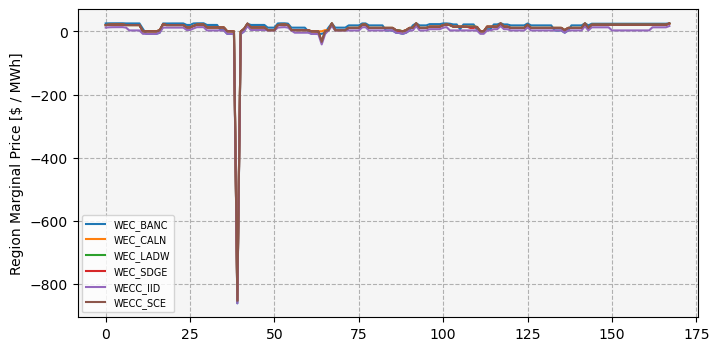

In [15]:
fig, ax = plt.subplots(1, 1, figsize = (8, 4))

for source, node in graph._node.items():

    ax.plot(
        np.array(results[source]['clearing_price']) * 3.6e9,
        label = source,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Region Marginal Price [$ / MWh]',
}

ax.set(**kw)

kw = {
    'ls': '--',
}

ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

ax.legend(**kw)

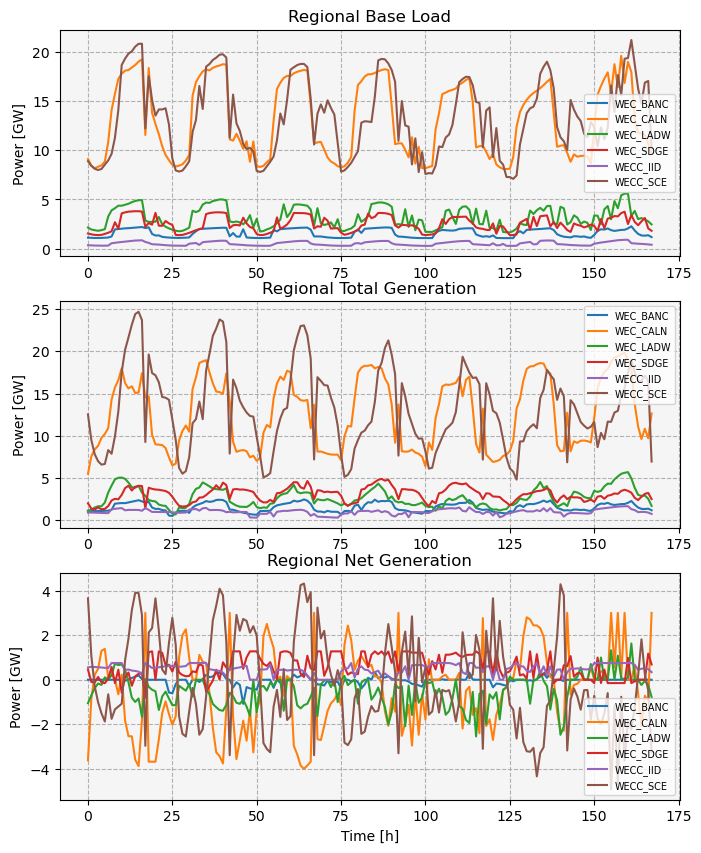

In [16]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in graph._node.items():

    ax[0].plot(
        -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
        label = source,
    )
    
    ax[0].set_title('Regional Base Load')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
    )

    ax[1].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[1].set_title('Regional Total Generation')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items()]
    )

    ax[2].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[2].set_title('Regional Net Generation')
    ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

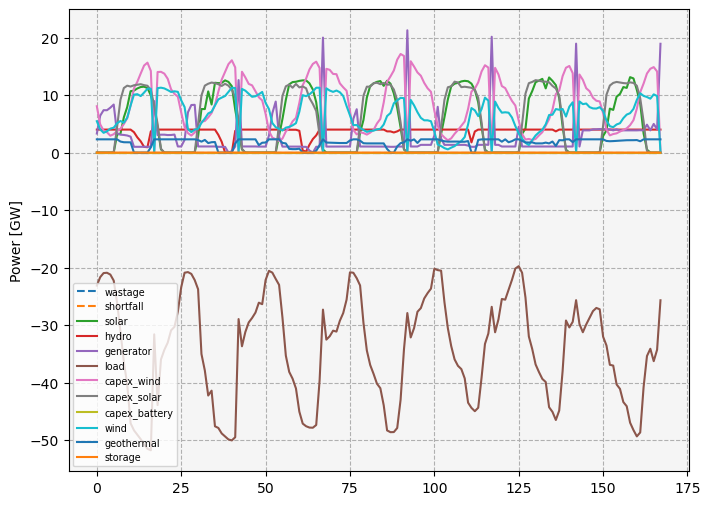

In [17]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

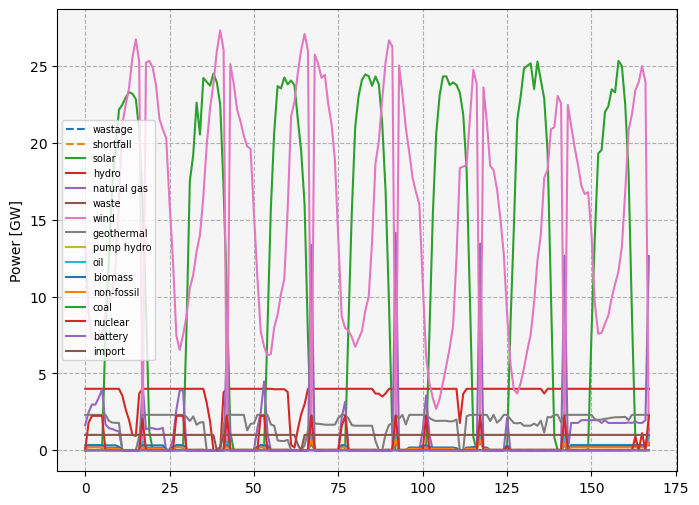

In [18]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in gen_amounts:

            gen_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

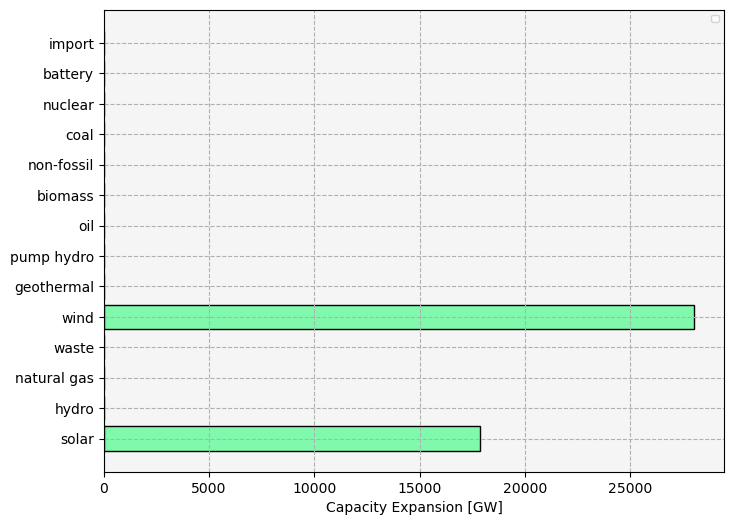

In [19]:
capex_amounts = {}

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in capex_amounts:

            capex_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['capex']]
            )

        else:

            capex_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['capex']]
            )

for key, val in capex_amounts.items():

    capex_amounts[key] = np.vstack(val).sum(axis = 0)[0] / 1e6

fig, ax = plt.subplots(figsize = (8, 6))

kw = {
    'color': 'xkcd:seafoam',
    'ec': 'k',
}

ax.barh(list(capex_amounts.keys()), list(capex_amounts.values()), **kw)

kw = {
    'facecolor': 'whitesmoke',
    'xlabel': 'Capacity Expansion [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)